## This section presents visualizaion for achieved results.

Two sets of adversarial images:

* 1st "stronger" set in "adversarial_images" folder with attacks parameters:
  * FGSM - eps=4/255
  * PGD - eps=4/255, alpha=2/255
  * CW - c=1, steps=300, lr=0.01
  * AutoAttack - eps=4/255
  * DeepFool -  steps=50, overshoot=0.02
  * OnePixel - pixels=1, steps=50, popsize=20

* 2nd "weaker" set in "new_adversarial_images" folder with attacks parameters:
  * FGSM - eps=2/255
  * PGD - eps=2/255, alpha=1/255
  * CW - c=1, steps=100, lr=0.01
  * AutoAttack - eps=2/255
  * DeepFool -  steps=50, overshoot=0.01
  * OnePixel - pixels=1, steps=50, popsize=100

Results for the 1st one are in:
* predictions.json
* metrics.json
* ssim_results.json

Results for the 2st one are in:
* new_predictions.json
* new_metrics.json
* new ssim results are omitted because oryginal have achieved high values and the purpose of this new set was to make differences less visible 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [30]:
# load results from a file
filepath = "metrics/metrics.csv"
filepath_ssim = "metrics/ssim_results.csv"
filepath_new = "metrics/new_metrics.csv"

df = pd.read_csv(filepath)
df_new = pd.read_csv(filepath_new)
df_ssim = pd.read_csv(filepath_ssim)
df_ssim

,model_type,attack,SSIM
0,VGG,FGSM,0.999412
1,VGG,PGD,0.999570
2,VGG,CW,0.999848
3,VGG,AutoAttack,0.999695
4,VGG,DeepFool,0.999853
5,VGG,OnePixel,0.999789
6,ResNet,FGSM,0.999404
7,ResNet,PGD,0.999622
8,ResNet,CW,0.999863
9,ResNet,AutoAttack,0.999700


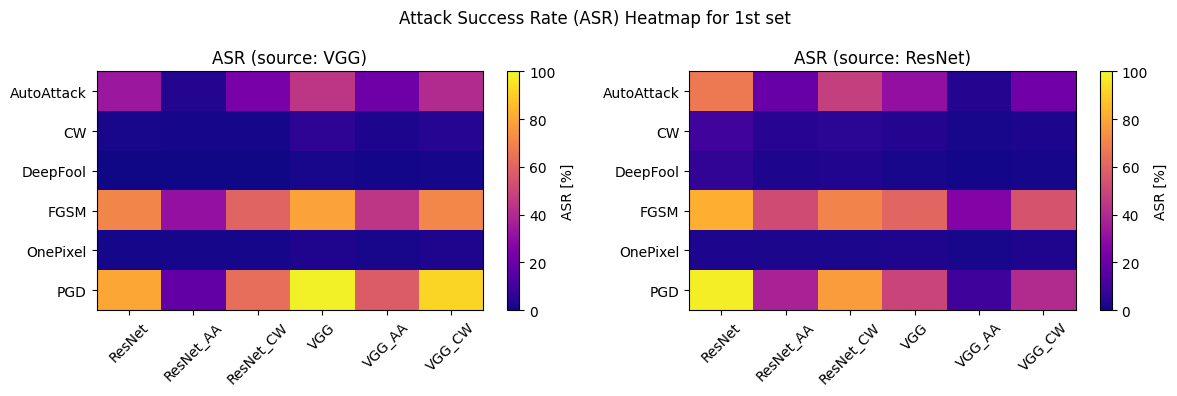

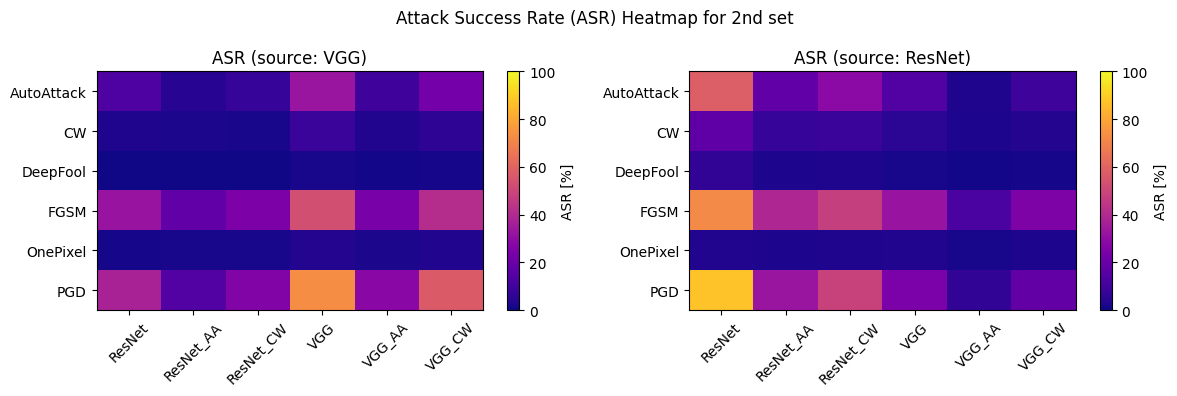

In [10]:
# heatmap of ASR for different attacks and models

def asr_heatmap(df, set):

    df_vgg = df[df["source"] == "VGG"]
    df_resnet = df[df["source"] == "ResNet"]

    pivot_vgg = df_vgg.pivot_table(
        index="attack",
        columns="target",
        values="asr",
    )

    pivot_resnet = df_resnet.pivot_table(
        index="attack",
        columns="target",
        values="asr"
    )

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    v_min = 0
    v_max = 100

    ax[0].imshow(pivot_vgg, aspect="auto", cmap = 'plasma', vmin=v_min, vmax=v_max)
    ax[0].set_title("ASR (source: VGG)")
    ax[0].set_xticks(range(len(pivot_vgg.columns)), pivot_vgg.columns, rotation=45)
    ax[0].set_yticks(range(len(pivot_vgg.index)), pivot_vgg.index)

    ax[1].imshow(pivot_resnet, aspect="auto", cmap = 'plasma', vmin=v_min, vmax=v_max)
    ax[1].set_title("ASR (source: ResNet)")
    ax[1].set_xticks(range(len(pivot_resnet.columns)), pivot_resnet.columns, rotation=45)  
    ax[1].set_yticks(range(len(pivot_resnet.index)), pivot_resnet.index)

    fig.colorbar(ax[1].images[0], label="ASR [%]")
    fig.colorbar(ax[0].images[0], label="ASR [%]")
    fig.suptitle(f"Attack Success Rate (ASR) Heatmap for {set} set")

    plt.tight_layout()
    plt.show()


asr_heatmap(df, "1st")
asr_heatmap(df_new, "2nd")

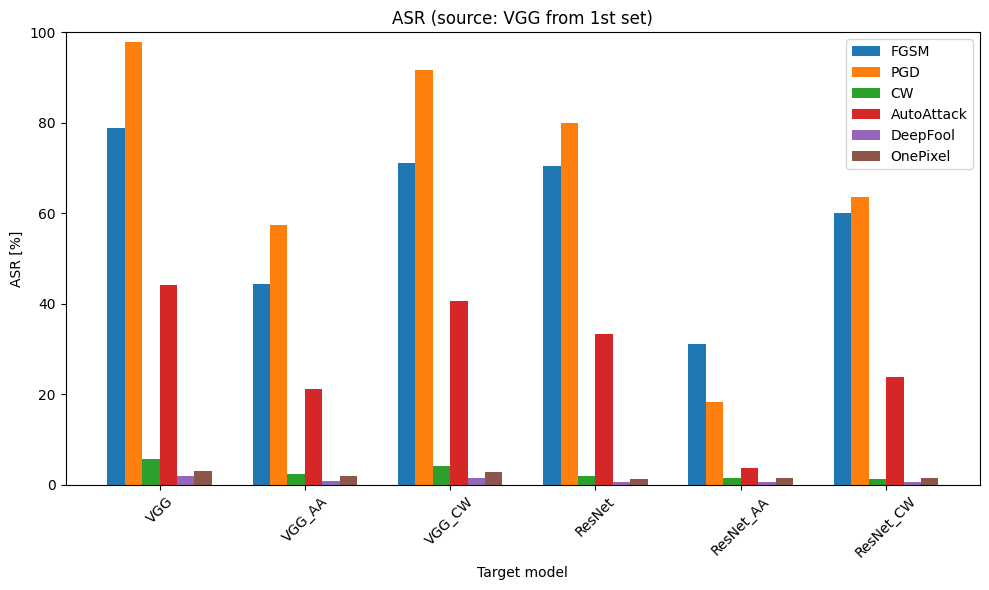

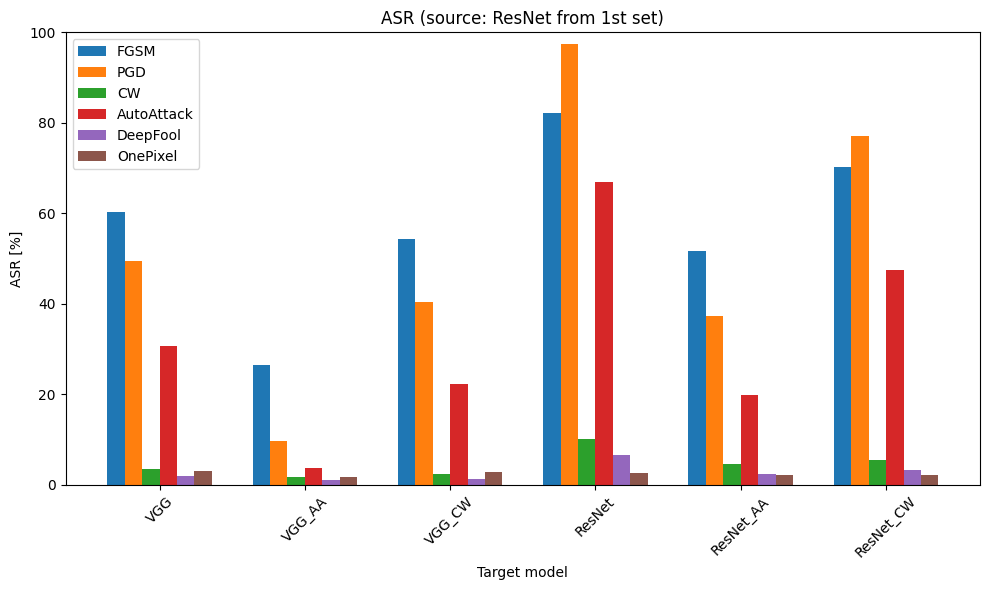

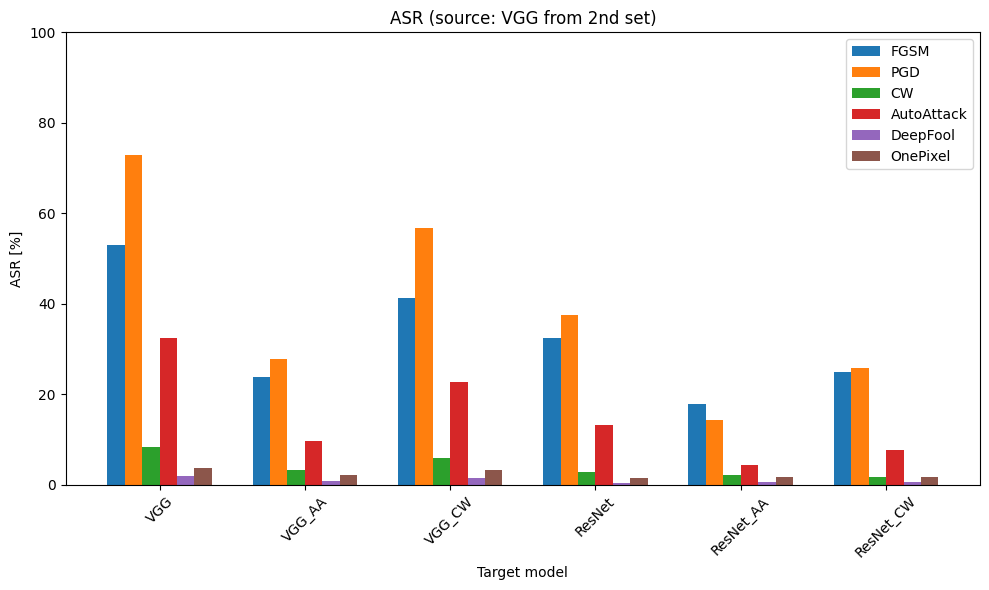

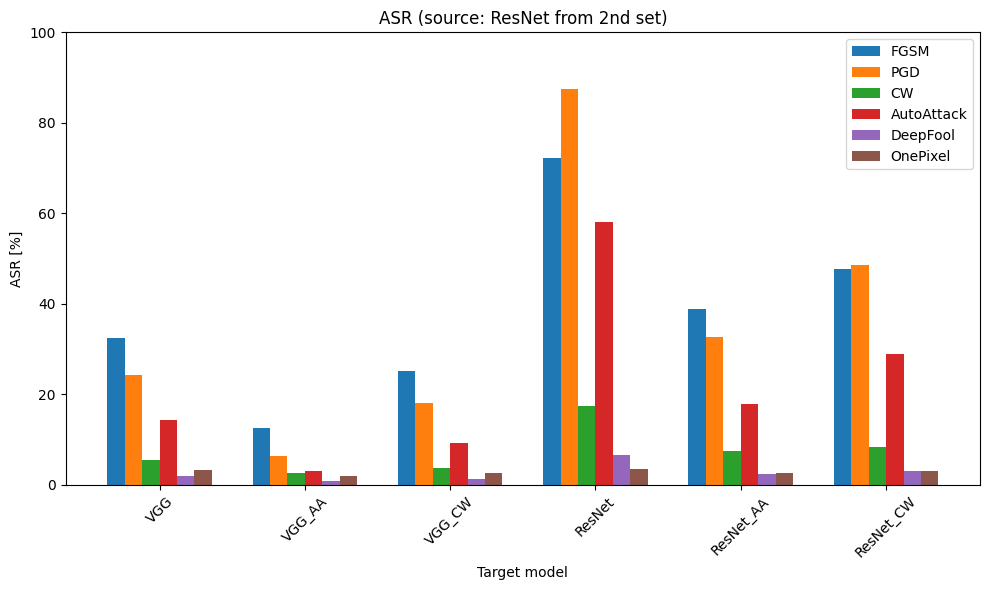

In [19]:
# bar plot of ASR for different attacks and target models for a fixed source model

def bar_asr_plot(df, source_model, set):
    subset = df[df["source"] == source_model]

    targets = subset["target"].unique()
    attacks = subset["attack"].unique()

    v_min = 0
    v_max = 100

    bar_width = 0.12
    x = np.arange(len(targets))

    plt.figure(figsize=(10, 6))

    for i, attack in enumerate(attacks):
        attack_data = subset[subset["attack"] == attack]
        attack_data = attack_data.set_index("target").reindex(targets)
        plt.bar(x + i*bar_width, attack_data["asr"], width=bar_width, label=attack)

    plt.xlabel("Target model")
    plt.ylabel("ASR [%]")
    plt.title(f"ASR (source: {source_model} from {set} set)")
    plt.xticks(x + bar_width*(len(attacks)/2-0.5), targets, rotation=45)
    plt.ylim(v_min, v_max)
    plt.legend()
    plt.tight_layout()
    plt.show()

bar_asr_plot(df, "VGG", "1st")
bar_asr_plot(df, "ResNet", "1st")
bar_asr_plot(df_new, "VGG", "2nd")
bar_asr_plot(df_new, "ResNet", "2nd")

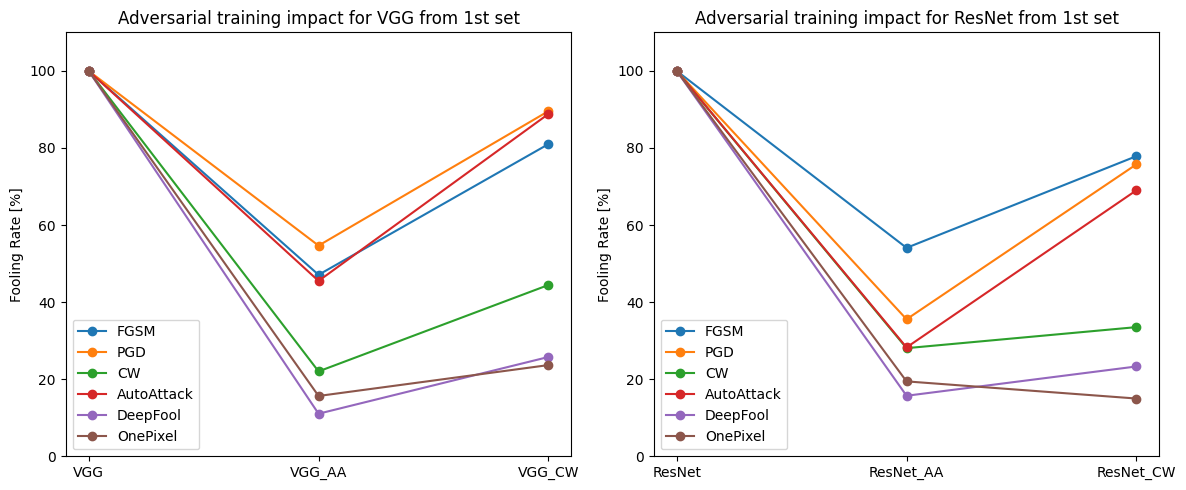

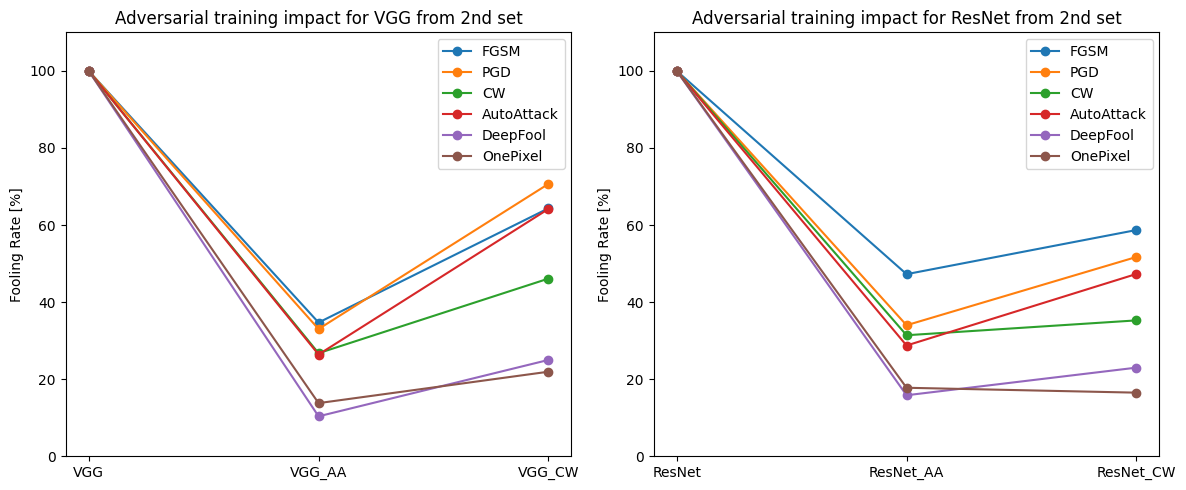

In [23]:
# line plot of fooling rate for different attacks and target models for a fixed source model

def fooling_rate_plot(df, set):

    targets_vgg = ["VGG", "VGG_AA", "VGG_CW"]
    df_vgg = df[(df["source"] == "VGG") & (df["target"].isin(targets_vgg))]

    targets_resnet = ["ResNet", "ResNet_AA", "ResNet_CW"]
    df_resnet = df[(df["source"] == "ResNet") & (df["target"].isin(targets_resnet))]

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    v_min = 0
    v_max = 110

    for attack in df_vgg["attack"].unique():
        vals = []
        for t in targets_vgg:
            vals.append(
                df_vgg[(df_vgg["attack"] == attack) & (df_vgg["target"] == t)]["fooling_rate"].mean()
            )
        ax[0].plot(targets_vgg, vals, marker="o", label=attack)

    ax[0].set_ylabel("Fooling Rate [%]")
    ax[0].set_title(f"Adversarial training impact for VGG from {set} set")
    ax[0].set_ylim(v_min, v_max)
    ax[0].legend()

    for attack in df_resnet["attack"].unique():
        vals = []
        for t in targets_resnet:
            vals.append(
                df_resnet[(df_resnet["attack"] == attack) & (df_resnet["target"] == t)]["fooling_rate"].mean()
            )
        ax[1].plot(targets_resnet, vals, marker="o", label=attack)

    ax[1].set_ylabel("Fooling Rate [%]")
    ax[1].set_title(f"Adversarial training impact for ResNet from {set} set")
    ax[1].set_ylim(v_min, v_max)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

fooling_rate_plot(df, "1st")
fooling_rate_plot(df_new, "2nd")

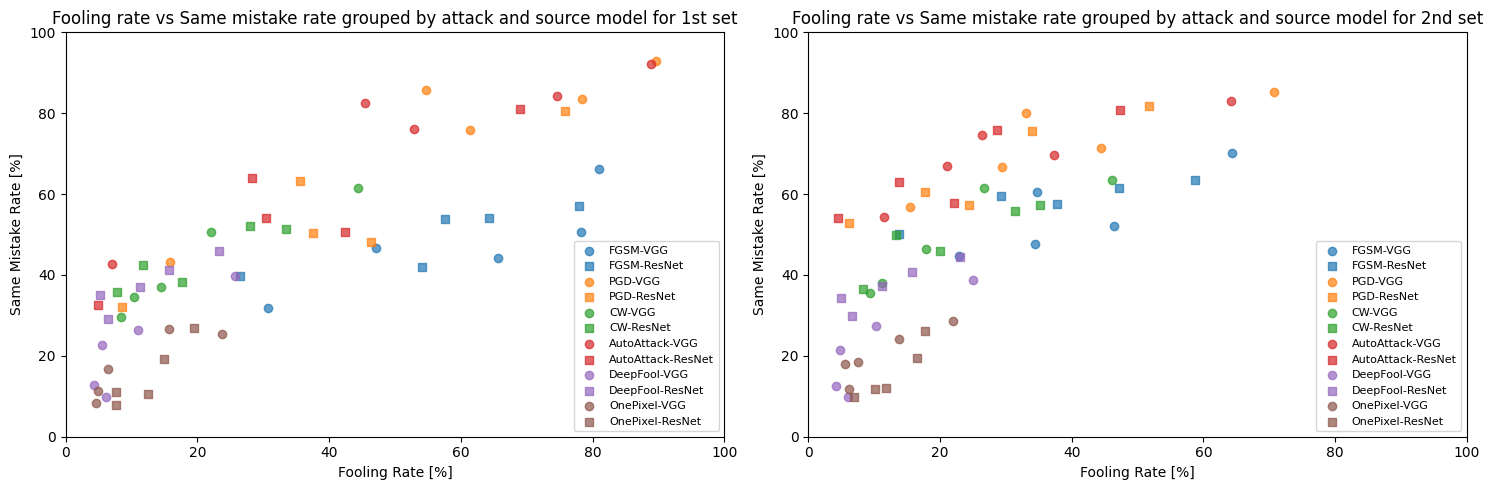

In [28]:
# scatter plot of fooling rate vs same mistake rate grouped by attack and source model

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

def scatter_fooling_vs_same_mistake(ax, df, set):

    v_min = 0
    v_max = 100

    attacks = df["attack"].unique()
    markers = {"VGG": "o", "ResNet": "s"}
    attack_colors = {
        "FGSM": "tab:blue",
        "PGD": "tab:orange",
        "CW": "tab:green",
        "AutoAttack": "tab:red",
        "DeepFool": "tab:purple",
        "OnePixel": "tab:brown"
    }

    for attack in attacks:
        subset = df[df["attack"] == attack]
        subset = subset[subset["target"] != subset["source"]]
        for src in subset["source"].unique():
            part = subset[subset["source"] == src]
            ax.scatter(
                part["fooling_rate"],
                part["same_mistake_rate"],
                color=attack_colors[attack],
                marker=markers[src],
                label=f"{attack}-{src}",
                alpha=0.7
            )

    ax.set_xlabel("Fooling Rate [%]")
    ax.set_ylabel("Same Mistake Rate [%]")
    ax.set_xlim(v_min, v_max)
    ax.set_ylim(v_min, v_max)
    ax.set_title(f"Fooling rate vs Same mistake rate grouped by attack and source model for {set} set")
    ax.legend(fontsize=8, loc="lower right")

scatter_fooling_vs_same_mistake(ax[0], df, "1st")
scatter_fooling_vs_same_mistake(ax[1], df_new, "2nd")   
plt.tight_layout()
plt.show()

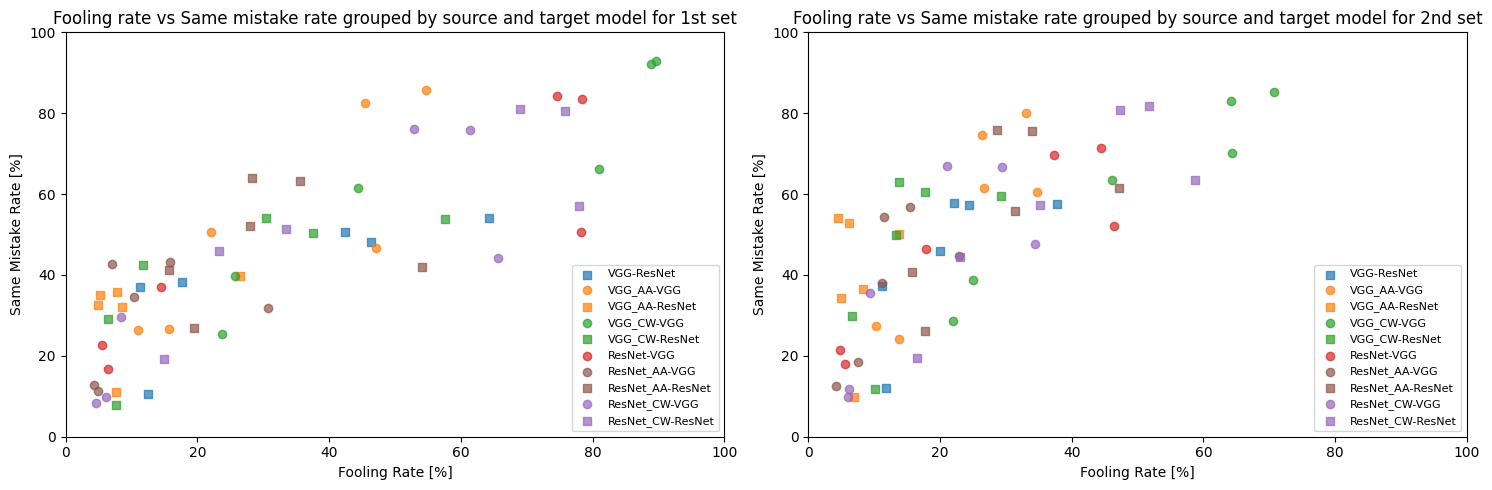

In [31]:
# scatter plot of fooling rate vs same mistake rate grouped by source and target model

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

def scatter_fooling_vs_same_mistake_models(ax, df, set):
    
    v_min = 0
    v_max = 100

    models = df["target"].unique()
    markers = {"VGG": "o", "ResNet": "s"}
    model_colors = {
        "VGG": "tab:blue",
        "VGG_AA": "tab:orange",
        "VGG_CW": "tab:green",
        "ResNet": "tab:red",
        "ResNet_CW": "tab:purple",
        "ResNet_AA": "tab:brown"
    }

    for model in models:
        subset = df[df["target"] == model]
        subset = subset[subset["target"] != subset["source"]]
        for src in subset["source"].unique():
            part = subset[subset["source"] == src]
            ax.scatter(
                part["fooling_rate"],
                part["same_mistake_rate"],
                color=model_colors[model],
                marker=markers[src],
                label=f"{model}-{src}",
                alpha=0.7
            )

    ax.set_xlabel("Fooling Rate [%]")
    ax.set_ylabel("Same Mistake Rate [%]")
    ax.set_xlim(v_min, v_max)
    ax.set_ylim(v_min, v_max)
    ax.set_title(f"Fooling rate vs Same mistake rate grouped by source and target model for {set} set")
    ax.legend(fontsize=8, loc="lower right")

scatter_fooling_vs_same_mistake_models(ax[0], df, "1st")
scatter_fooling_vs_same_mistake_models(ax[1], df_new, "2nd")
plt.tight_layout()
plt.show()

## Analysis of impact on different classes

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import torchvision.transforms as transforms
import torchvision

filepath_results = "metrics/predictions.json"
df = pd.read_json(filepath_results)

filepath_new_results = "metrics/new_predictions.json"
df_new = pd.read_json(filepath_new_results)

mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
labels_map = test_set.classes
labels = test_set.targets

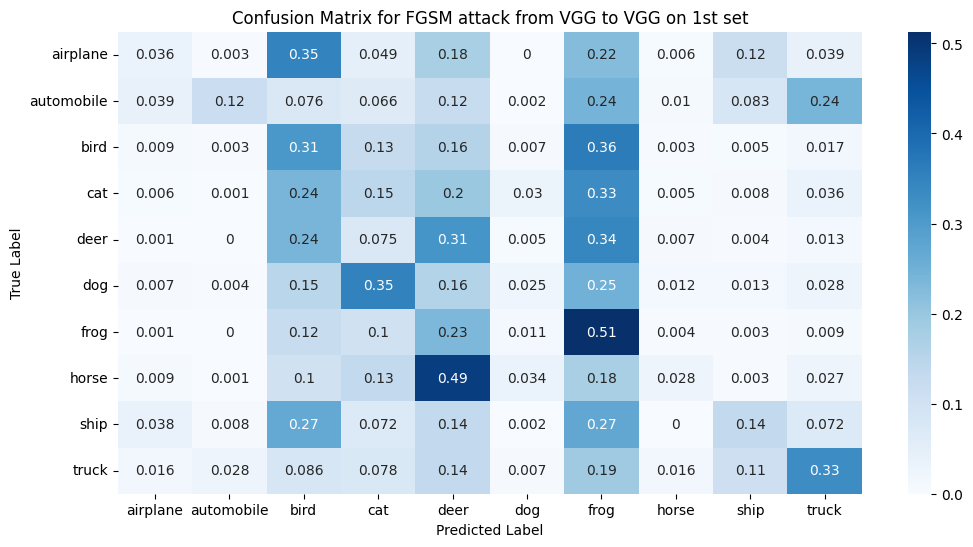

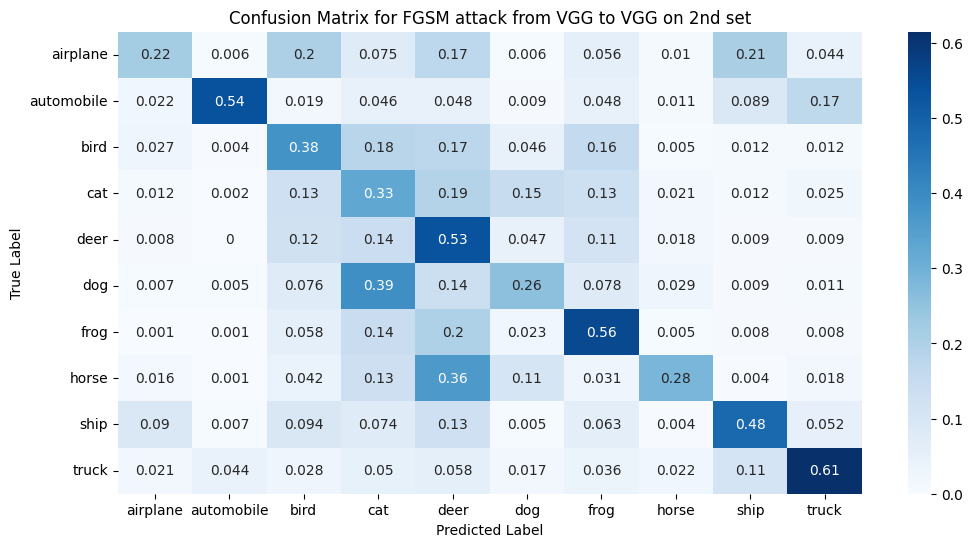

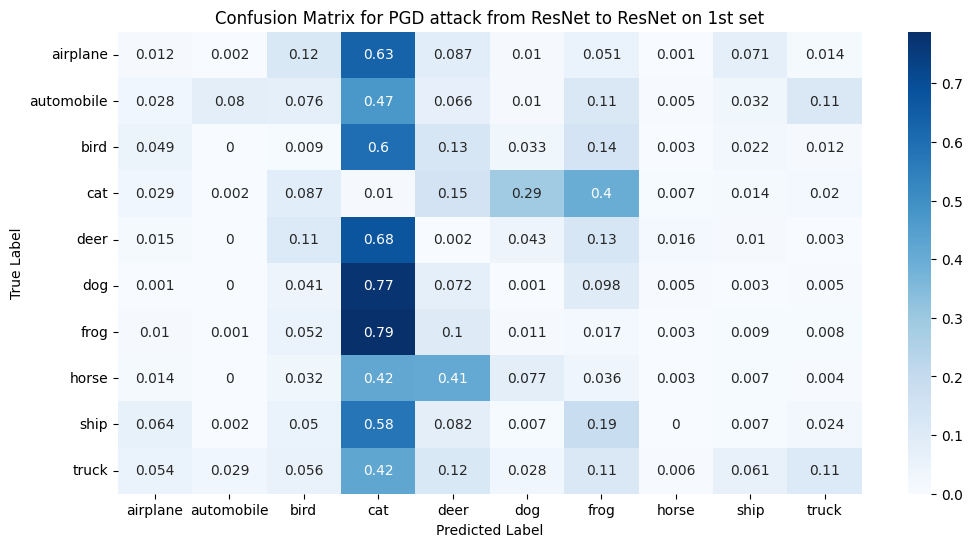

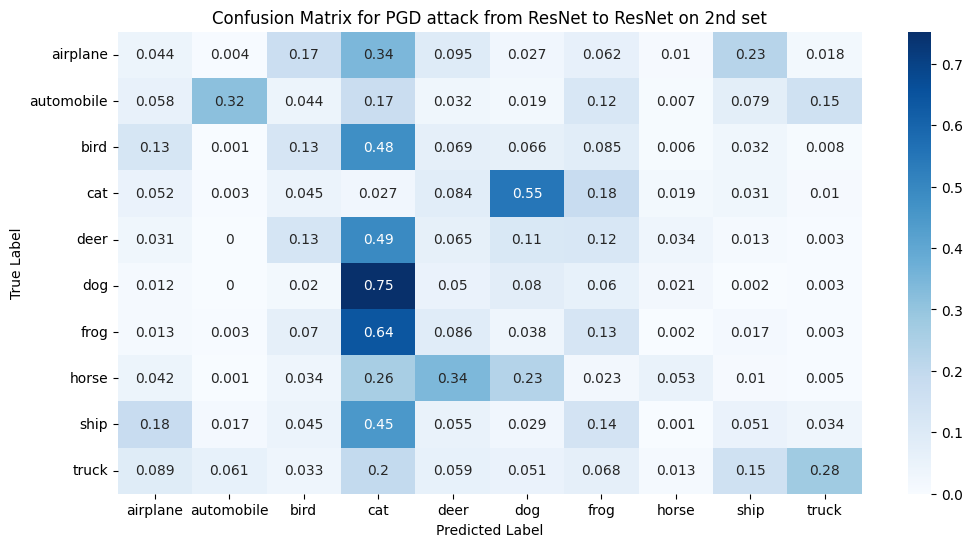

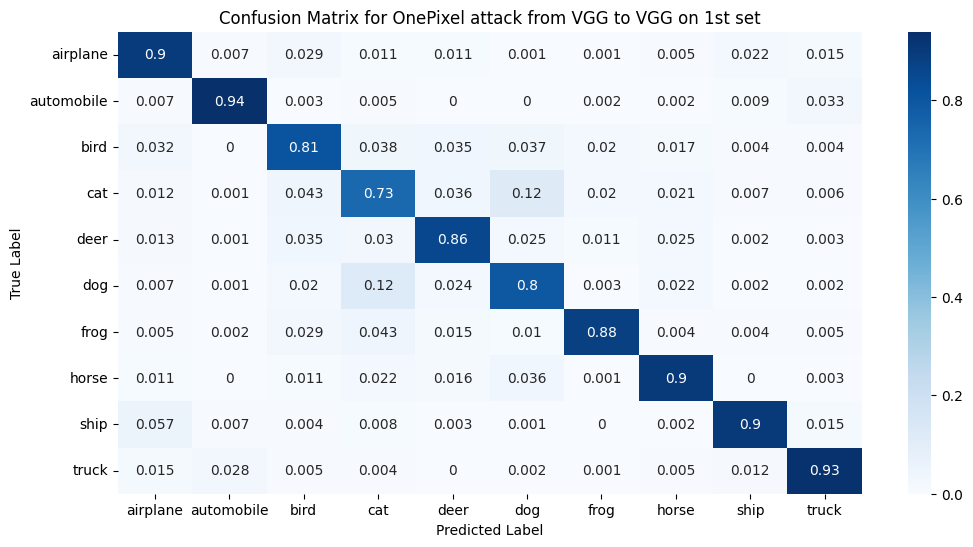

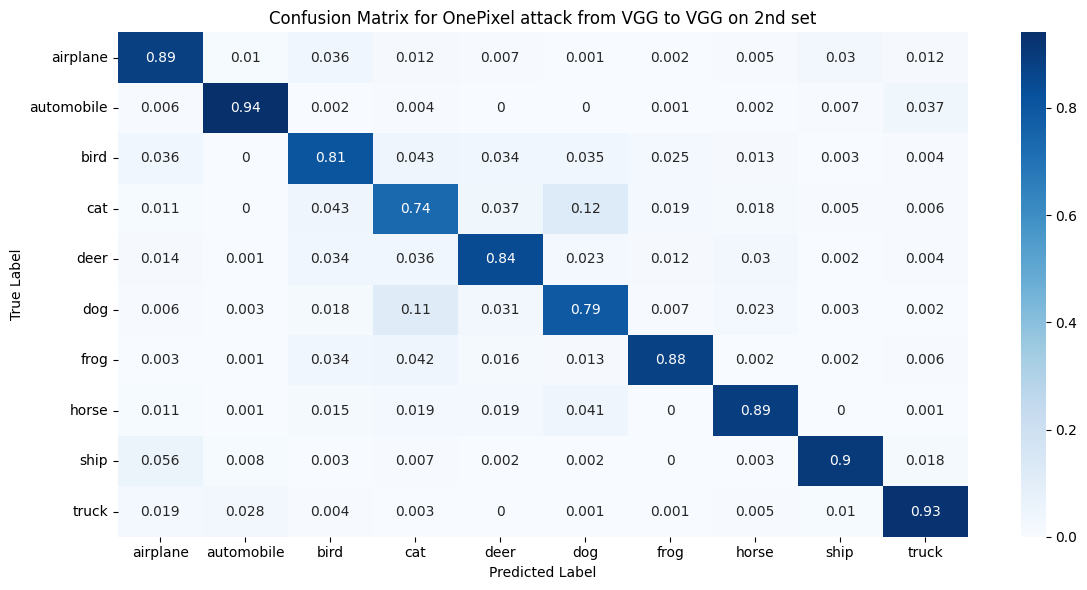

In [59]:
# confusion matrix for attacks on different models

def plot_confusion_matrix(df, source_model, target_model, attack, set):
    attack_results = df[f"{source_model}_{attack}_{target_model}"].tolist()
    cm = confusion_matrix(labels, attack_results)
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(cm/np.sum(cm)*10, annot=True, cmap='Blues', xticklabels=labels_map, yticklabels=labels_map)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {attack} attack from {source_model} to {target_model} on {set} set')


plot_confusion_matrix(df, "VGG", "VGG", "FGSM", "1st")
plot_confusion_matrix(df_new, "VGG", "VGG", "FGSM", "2nd")

plot_confusion_matrix(df, "ResNet", "ResNet", "PGD", "1st")
plot_confusion_matrix(df_new, "ResNet", "ResNet", "PGD", "2nd")

plot_confusion_matrix(df, "VGG", "VGG", "OnePixel", "1st")
plot_confusion_matrix(df_new, "VGG", "VGG", "OnePixel", "2nd")

plt.tight_layout()
plt.show()

TO DO:
- opisać słownie wyniki